# Domain Adaptation Pipeline: NIDS
**Goal:** Fix the "Reality Gap" using **Covariate Shift Adaptation**.

**The "Nuclear" Technique: Instance Weighting**
Instead of trusting all training data equally, we mathematically calculate which training rows resemble the real world (NSL-KDD) and force the model to focus ONLY on them.

**Steps:**
1.  **Target Encoding:** Replaces sparse One-Hot vectors with dense probability features.
2.  **Density Ratio Estimation:** Train a classifier to predict "Is this Test Data?".
3.  **Importance Weighting:** $Weight = P(Test) / P(Train)$.
4.  **Weighted XGBoost:** Train the final model using these weights.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
from xgboost import XGBClassifier

# Config
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

## 1. Data Loading & Alignment

In [2]:
DATA_DIR = 'Data'
CSV_FILE = os.path.join(DATA_DIR, 'network_connections.csv')
MAP_FILE = os.path.join(DATA_DIR, 'attack2category_map.txt')
NSL_URL = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTest%2B.txt"

# Load Mapping
attack_map = {'normal': 'normal'}
try:
    with open(MAP_FILE, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 2:
                attack_map[parts[0]] = parts[1]
except FileNotFoundError:
    print("Warning: Map file not found.")

# --- Load Training Data (KDD99) ---
df_train = pd.read_csv(CSV_FILE)
df_train['label'] = df_train['label'].astype(str).str.replace('.', '', regex=False)
df_train['category'] = df_train['label'].map(attack_map).fillna('other')
df_train.drop_duplicates(inplace=True)

# --- Load Test Data (NSL-KDD) ---
NSL_COLS = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins',
    'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root',
    'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds',
    'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate',
    'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
    'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
    'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate',
    'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
    'dst_host_srv_rerror_rate', 'label', 'difficulty_level'
]
df_test = pd.read_csv(NSL_URL, header=None, names=NSL_COLS)
df_test.drop('difficulty_level', axis=1, inplace=True)
df_test['label'] = df_test['label'].astype(str).str.replace('.', '', regex=False)
df_test['category'] = df_test['label'].map(attack_map).fillna('other')

# Log Transform Bytes (Standard Practice)
for col in ['src_bytes', 'dst_bytes', 'duration']:
    df_train[col] = np.log1p(df_train[col])
    df_test[col] = np.log1p(df_test[col])

print(f"Train Shape: {df_train.shape} | Test Shape: {df_test.shape}")

Train Shape: (125973, 43) | Test Shape: (22544, 43)


## 2. Target Encoding (Better than One-Hot)
One-Hot encoding creates too many columns. Target Encoding replaces categories with the "risk probability". This forces the model to learn the *value* of a service (e.g., http vs ftp) rather than just its name.

In [3]:
# Separate Target
y_train = df_train['category']
y_test = df_test['category']

# Encode Target Labels to Integers
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

cat_cols = ['protocol_type', 'service', 'flag']
numeric_cols = [c for c in df_train.columns if c not in cat_cols + ['label', 'category']]

# --- Robust Target Encoding with Smoothing ---
# We do this manually to avoid external library dependency issues
def target_encode(train_df, test_df, cols, target):
    train_encoded = train_df.copy()
    test_encoded = test_df.copy()
    
    # Create a binary target (Attack vs Normal) for encoding to prevent leakage of specific classes
    binary_target = (target != 'normal').astype(int)
    train_encoded['temp_target'] = binary_target
    
    global_mean = binary_target.mean()
    
    for col in cols:
        # Calculate mean target per category
        agg = train_encoded.groupby(col)['temp_target'].agg(['mean', 'count'])
        counts = agg['count']
        means = agg['mean']
        
        # Smoothing (prevents overfitting on rare categories)
        smooth_weight = 10  # Weight for global mean
        smoothed_means = (counts * means + smooth_weight * global_mean) / (counts + smooth_weight)
        
        # Map to Train and Test
        train_encoded[col] = train_encoded[col].map(smoothed_means).fillna(global_mean)
        test_encoded[col] = test_encoded[col].map(smoothed_means).fillna(global_mean)
    
    return train_encoded.drop('temp_target', axis=1), test_encoded

# Apply Encoding
X_train_enc, X_test_enc = target_encode(df_train.drop(['label', 'category'], axis=1), 
                                        df_test.drop(['label', 'category'], axis=1), 
                                        cat_cols, y_train)

print("Target Encoding Complete. Features are now dense probabilities.")

Target Encoding Complete. Features are now dense probabilities.


## 3. Instance Weighting (The "Nuclear" Option)
We calculate $w = P(Test) / P(Train)$.
This down-weights training samples that are irrelevant to the real world.

In [4]:
print("--- Calculating Covariate Shift Weights ---")

# 1. Tag Data: Train=0, Test=1
X_train_enc['is_test'] = 0
X_test_enc['is_test'] = 1

# 2. Combine
X_combined = pd.concat([X_train_enc, X_test_enc], axis=0)
y_combined = X_combined.pop('is_test')

# 3. Train Classifier (Random Forest is robust here)
# We want to see if we can separate Train from Test
domain_clf = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42, n_jobs=-1)
domain_clf.fit(X_combined, y_combined)

# 4. Predict "Probablity of being Test Data" for the Training Set
probs = domain_clf.predict_proba(X_train_enc.drop('is_test', axis=1, errors='ignore'))[:, 1]

# 5. Calculate Weights: w = p / (1 - p)
# p is prob of being Test. 1-p is prob of being Train.
# Epsilon prevents division by zero
epsilon = 1e-5
weights = probs / (1 - probs + epsilon)

# Normalize weights to keep scale reasonable
weights = weights / weights.mean()

# Clip extreme weights to prevent instability
weights = np.clip(weights, 0, 5)

print("Weights Calculated.")
print(f"Average Weight: {weights.mean():.2f}")
print(f"Max Weight: {weights.max():.2f} (These samples look exactly like Test Data)")
print(f"Min Weight: {weights.min():.2f} (These samples are useless KDD artifacts)")

# Clean up columns
if 'is_test' in X_train_enc.columns: X_train_enc.drop('is_test', axis=1, inplace=True)
if 'is_test' in X_test_enc.columns: X_test_enc.drop('is_test', axis=1, inplace=True)

--- Calculating Covariate Shift Weights ---
Weights Calculated.
Average Weight: 1.00
Max Weight: 5.00 (These samples look exactly like Test Data)
Min Weight: 0.19 (These samples are useless KDD artifacts)


## 4. Weighted Training
We train XGBoost, but we pass the `weights`. The model effectively ignores the "garbage" data.

--- Training Weighted XGBoost ---

>>> Weighted Model Accuracy (NSL-KDD): 77.28%

Classification Report:
              precision    recall  f1-score   support

         dos       0.96      0.79      0.87      7636
      normal       0.68      0.97      0.80      9711
       probe       0.85      0.74      0.79      2423
         r2l       0.98      0.06      0.11      2574
         u2r       0.56      0.03      0.05       200

    accuracy                           0.77     22544
   macro avg       0.80      0.52      0.52     22544
weighted avg       0.82      0.77      0.73     22544



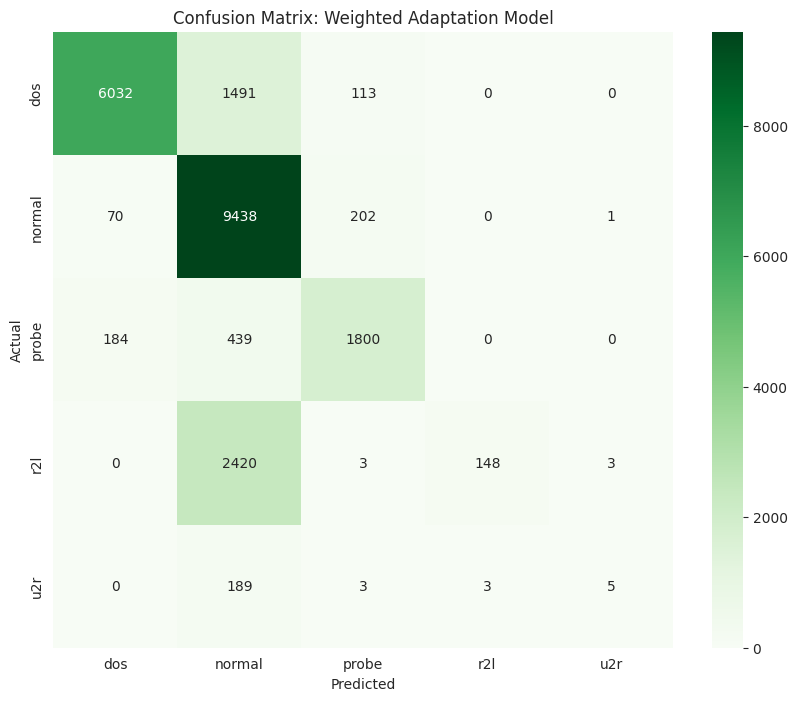

In [5]:
print("--- Training Weighted XGBoost ---")

clf_final = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',
    n_jobs=-1,
    random_state=42
)

# KEY STEP: Pass sample_weight
clf_final.fit(X_train_enc, y_train_enc, sample_weight=weights)

# Evaluate
y_test_pred = clf_final.predict(X_test_enc)
y_test_pred_cat = le.inverse_transform(y_test_pred)

acc = accuracy_score(y_test, y_test_pred_cat)
print(f"\n>>> Weighted Model Accuracy (NSL-KDD): {acc:.2%}")

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_cat))

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred_cat, labels=le.classes_)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix: Weighted Adaptation Model")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()